In [131]:
import pandas as pd

# prevent false warning
# https://stackoverflow.com/questions/20625582/how-to-deal-with-settingwithcopywarning-in-pandas
pd.options.mode.chained_assignment = None  # default='warn'

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

import geopandas as gdf

## Birdhides

In [135]:
gdf_birdhides = gdf.read_file('Birdhides.shp')
gdf_birdhides = gdf_birdhides.to_crs(epsg=4326)

In [136]:
gdf_birdhides.head()

,Name,Name_Alias,Lat_DD,Long_DD,geometry
0,Nthandanyathi Bird Hide,Nthandanyathi,-25.207329,31.959580,POINT (31.95958 -25.20733)
1,Lake Panic Bird Hide,Lake Panic,-24.981318,31.566089,POINT (31.56609 -24.98132)
2,Sweni Bird Hide,Sweni,-24.473604,31.973105,POINT (31.97311 -24.47360)
3,Ratel Pan Bird Hide,Ratel Pan,-24.242064,31.642755,POINT (31.64276 -24.24206)
4,Sable Dam Bird Hide,Sable Dam,-23.939594,31.239261,POINT (31.23926 -23.93959)


In [137]:
gdf_birdhides['Type'] = 'Bird hide'
gdf_birdhides['Access'] = 'Public' # ?
gdf_birdhides.drop(['Name_Alias', 'Lat_DD', 'Long_DD'], axis=1, inplace=True)

In [139]:
gdf_birdhides.head()

,Name,geometry,Type,Access
0,Nthandanyathi Bird Hide,POINT (31.95958 -25.20733),Bird hide,Public
1,Lake Panic Bird Hide,POINT (31.56609 -24.98132),Bird hide,Public
2,Sweni Bird Hide,POINT (31.97311 -24.47360),Bird hide,Public
3,Ratel Pan Bird Hide,POINT (31.64276 -24.24206),Bird hide,Public
4,Sable Dam Bird Hide,POINT (31.23926 -23.93959),Bird hide,Public


## Camps

In [145]:
gdf_camps = gdf.read_file('camps_all.shp')
gdf_camps = gdf_camps.to_crs(epsg=4326)

In [146]:
gdf_camps.head()

,NAME,DESCRIPT,BOREHOLE,OPERATIONL,SYNONYM,ACCESS,TYPE,geometry
0,Bateleur,None,Y,Y,None,Public,Bushveld camp,POINT (31.20136 -23.23343)
1,Berg-en-Dal,None,N,Y,None,Public,Rest camp,POINT (31.44432 -25.42813)
2,Biyamiti,None,Y,Y,None,Public,Bushveld camp,POINT (31.71035 -25.30811)
3,Boulders,None,Y,Y,None,Private,Bush Lodge,POINT (31.37501 -23.60793)
4,Crocodile Bridge,None,N,Y,None,Public,Rest camp,POINT (31.89330 -25.35823)


In [147]:
gdf_camps['ACCESS'].value_counts()

Private    53
Staff      23
Public     22
Name: ACCESS, dtype: int64

In [148]:
gdf_camps['TYPE'].value_counts()

Concession camp         29
Rest camp               12
Ranger camp             11
Staff Accommodation     11
Trails camp              8
Bushveld camp            5
Satellite camp           5
SANDF Base               5
Bush Lodge               3
Unspecified              3
HR camp                  2
Backpack camp            1
Kennels/ K9 training     1
4X4 Camp                 1
EE Centre                1
Name: TYPE, dtype: int64

In [149]:
gdf_camps.replace({'BOREHOLE': {'Y': True, 'N': False}}, inplace=True)
gdf_camps.replace({'OPERATIONL': {'Y': True, 'N': False}}, inplace=True)

gdf_camps.rename(columns={'NAME': 'Name', 'DESCRIPT': 'Description', 'ACCESS': 'Access', 'TYPE': 'Type'}, inplace=True)

In [150]:
gdf_camps.head()

,Name,Description,BOREHOLE,OPERATIONL,SYNONYM,Access,Type,geometry
0,Bateleur,None,True,True,None,Public,Bushveld camp,POINT (31.20136 -23.23343)
1,Berg-en-Dal,None,False,True,None,Public,Rest camp,POINT (31.44432 -25.42813)
2,Biyamiti,None,True,True,None,Public,Bushveld camp,POINT (31.71035 -25.30811)
3,Boulders,None,True,True,None,Private,Bush Lodge,POINT (31.37501 -23.60793)
4,Crocodile Bridge,None,False,True,None,Public,Rest camp,POINT (31.89330 -25.35823)


## Gates

In [151]:
gdf_gates = gdf.read_file('gates_public.shp')
gdf_gates = gdf_gates.to_crs(epsg=4326)


In [152]:
gdf_gates.head()

,OBJECTID,NAME,TYPE,Access,Lat_DD,Long_DD,geometry
0,1,Crocodile Bridge,KNP Gate,Public,-25.358481,31.892587,POINT (31.89259 -25.35848)
1,2,Malelane,KNP Gate,Public,-25.462242,31.532248,POINT (31.53225 -25.46224)
2,4,Numbi,KNP Gate,Public,-25.155235,31.197791,POINT (31.19779 -25.15524)
3,5,Pafuri,KNP Gate,Public,-22.399849,31.041282,POINT (31.04128 -22.39985)
4,6,Phalaborwa,KNP Gate,Public,-23.945703,31.166062,POINT (31.16606 -23.94570)


In [153]:
gdf_gates['Access'].value_counts()

Public     12
Private     1
Name: Access, dtype: int64

In [154]:
gdf_gates['TYPE'].value_counts()

KNP Gate         10
Port of Entry     2
Private Gate      1
Name: TYPE, dtype: int64

In [155]:
gdf_gates.rename(columns={'NAME': 'Name', 'TYPE': 'Type'}, inplace=True)
gdf_gates.drop(['Lat_DD', 'Long_DD', 'OBJECTID'], axis=1, inplace=True)

In [156]:
gdf_gates.head()

,Name,Type,Access,geometry
0,Crocodile Bridge,KNP Gate,Public,POINT (31.89259 -25.35848)
1,Malelane,KNP Gate,Public,POINT (31.53225 -25.46224)
2,Numbi,KNP Gate,Public,POINT (31.19779 -25.15524)
3,Pafuri,KNP Gate,Public,POINT (31.04128 -22.39985)
4,Phalaborwa,KNP Gate,Public,POINT (31.16606 -23.94570)


## Tourist sites

In [157]:
gdf_sites = gdf.read_file('tourist_sites.shp')
gdf_sites = gdf_sites.to_crs(epsg=4326)

gdf_sites['BOREHOLE'] = gdf_sites['BOREHOLE'].astype(bool)
gdf_sites['PICNICSITE'] = gdf_sites['PICNICSITE'].astype(bool)
gdf_sites['GET_OUT'] = gdf_sites['GET_OUT'].astype(bool)
gdf_sites['LOOK_OUT'] = gdf_sites['LOOK_OUT'].astype(bool)
gdf_sites['WATERHOLE'] = gdf_sites['WATERHOLE'].astype(bool)
gdf_sites['DAM'] = gdf_sites['DAM'].astype(bool)
gdf_sites['KOP'] = gdf_sites['KOP'].astype(bool)
gdf_sites['RUIN'] = gdf_sites['RUIN'].astype(bool)

In [159]:
gdf_sites.head()

,OBJECTID,NAME,DESCRIPT,SYNONYM,BOREHOLE,PICNICSITE,GET_OUT,LOOK_OUT,WATERHOLE,DAM,KOP,RUIN,TYPE,geometry
0,1,Afsaal,Picnic spot,None,True,True,False,False,False,False,False,False,Picnic spot,POINT (31.53270 -25.28679)
1,2,Mooiplaas,Picnic spot,Mooi Plaas,True,True,False,False,False,False,False,False,Picnic spot,POINT (31.44098 -23.55588)
2,3,Muzandzeni,Picnic spot,Mzanzene,True,True,False,False,False,False,False,False,Picnic spot,POINT (31.63474 -24.48167)
3,4,Nkuhlu,Picnic spot,None,False,True,False,False,False,False,False,False,Picnic spot,POINT (31.76912 -24.99692)
4,5,Pafuri,Picnic spot,None,False,True,False,False,False,False,False,False,Picnic spot,POINT (31.24739 -22.42276)


In [160]:
gdf_sites.rename(columns={'NAME': 'Name', 'DESCRIPT': 'Description', 'TYPE': 'Type'}, inplace=True)
gdf_sites.drop(['OBJECTID'], axis=1, inplace=True)

In [161]:
gdf_sites['Access'] = 'Public' # ?

In [162]:
gdf_sites.head()

,Name,Description,SYNONYM,BOREHOLE,PICNICSITE,GET_OUT,LOOK_OUT,WATERHOLE,DAM,KOP,RUIN,Type,geometry,Access
0,Afsaal,Picnic spot,None,True,True,False,False,False,False,False,False,Picnic spot,POINT (31.53270 -25.28679),Public
1,Mooiplaas,Picnic spot,Mooi Plaas,True,True,False,False,False,False,False,False,Picnic spot,POINT (31.44098 -23.55588),Public
2,Muzandzeni,Picnic spot,Mzanzene,True,True,False,False,False,False,False,False,Picnic spot,POINT (31.63474 -24.48167),Public
3,Nkuhlu,Picnic spot,None,False,True,False,False,False,False,False,False,Picnic spot,POINT (31.76912 -24.99692),Public
4,Pafuri,Picnic spot,None,False,True,False,False,False,False,False,False,Picnic spot,POINT (31.24739 -22.42276),Public


## Waterpoints

In [164]:
gdf_waterpoints = gdf.read_file('Waterpoints_zambatis_2016.shp')
gdf_waterpoints = gdf_waterpoints.to_crs(epsg=4326)


In [165]:
gdf_waterpoints.head()

,NAME,TYPE,RANGER_SEC,HOLE_DRILL,BOREHOLE_D,BOREHOLE_1,STRUCTURES,PURPOSE,STATUS___S,REHABILITA,LOCALITY,Y_COORD,X_COORD,NOTES___CO,Label,Lable_Name,Label_Type,geometry
0,Afsaal,Borehole,MAL,1983,60/5,5450,SRT,D,O-RO,N/A,Afsaal picnic site,-25.28517,31.53319,None,Open,Afsaal,Borehole,POINT (31.53319 -25.28517)
1,Ampie,Borehole,MAL,c1973,31/8,1703,SRT,W,O-RO,N/A,13 km NNE Malelane,-25.35544,31.52741,None,Open,Ampie,Borehole,POINT (31.52741 -25.35544)
2,Babalala,Boreholes (2),VLA,?,11/-,1514,S,W & D,DRT & D,N/A,5 km SSE Vlakteplaas,-22.90582,31.24928,"Two boreholes at Babalala, providing water for...",Drought,Babalala,Borehole,POINT (31.24928 -22.90582)
3,Babalala,Boreholes (2),VLA,?,30/1,14985,S,W & D,DRT & D,N/A,5 km SSE Vlakteplaas,-22.90582,31.24928,"Two boreholes at Babalala, providing water for...",Drought,Babalala,Borehole,POINT (31.24928 -22.90582)
4,Balule,Borehole,HOU,?,85/-,5678,D,D,O-RO,N/A,6 km S Olifants,-24.05454,31.73373,None,Open,Balule,Borehole,POINT (31.73373 -24.05454)


In [166]:
gdf_waterpoints['TYPE'].value_counts()

Borehole                        42
Dam, earthen                    19
Borehole No. 1                  14
Borehole No. 2                  14
Dam, concrete                   12
Pipeline trough                  6
Dam, concrete weir               6
Borehole No. 1 N                 4
Borehole No. 3                   3
Borehole No. 1 SW                3
Borehole No. 2 E                 3
Borehole No. 2 S                 2
Boreholes (2)                    2
Borehole No. 2 SE                2
Borehole No. 1 SE                2
Borehole No. 1 W                 2
Borehole S                       2
Borehole No. 3 W                 1
Borehole No. 2 >w                1
Borehole E-48                    1
Borehole No. 2 W                 1
Borehole N                       1
Borehole WSW                     1
Borehole No. 1 E                 1
Borehole N-75                    1
Borehole No. 2 SSE-150           1
Borehole No. 1 SSW-100           1
Borehole No. 2 NW                1
Borehole No. 2 SSW  

In [167]:
gdf_waterpoints['Label_Type'].value_counts()

Borehole              118
Dam, earthen           19
Dam, concrete          12
Dam, concrete weir      7
Pipeline trough         6
Name: Label_Type, dtype: int64

In [168]:
gdf_waterpoints.rename(columns={'TYPE': 'TYPE_ORIGINAL', 'Label_Type': 'Type', 'NAME': 'Name'}, inplace=True)
gdf_waterpoints.drop(['Y_COORD', 'X_COORD'], axis=1, inplace=True)

gdf_waterpoints['Access'] = 'Public' # ?

In [169]:
gdf_waterpoints.head()

,Name,TYPE_ORIGINAL,RANGER_SEC,HOLE_DRILL,BOREHOLE_D,BOREHOLE_1,STRUCTURES,PURPOSE,STATUS___S,REHABILITA,LOCALITY,NOTES___CO,Label,Lable_Name,Type,geometry,Access
0,Afsaal,Borehole,MAL,1983,60/5,5450,SRT,D,O-RO,N/A,Afsaal picnic site,None,Open,Afsaal,Borehole,POINT (31.53319 -25.28517),Public
1,Ampie,Borehole,MAL,c1973,31/8,1703,SRT,W,O-RO,N/A,13 km NNE Malelane,None,Open,Ampie,Borehole,POINT (31.52741 -25.35544),Public
2,Babalala,Boreholes (2),VLA,?,11/-,1514,S,W & D,DRT & D,N/A,5 km SSE Vlakteplaas,"Two boreholes at Babalala, providing water for...",Drought,Babalala,Borehole,POINT (31.24928 -22.90582),Public
3,Babalala,Boreholes (2),VLA,?,30/1,14985,S,W & D,DRT & D,N/A,5 km SSE Vlakteplaas,"Two boreholes at Babalala, providing water for...",Drought,Babalala,Borehole,POINT (31.24928 -22.90582),Public
4,Balule,Borehole,HOU,?,85/-,5678,D,D,O-RO,N/A,6 km S Olifants,None,Open,Balule,Borehole,POINT (31.73373 -24.05454),Public


# Merge


- `Type`: `Rest camp`, `Birdhide`, …
- `Access`: `Public`, `Staff`, `Private`


In [170]:
frames = [gdf_birdhides, gdf_camps, gdf_gates, gdf_sites, gdf_waterpoints]
gdf = pd.concat(frames)

In [189]:
gdf.head()

,Name,geometry,Type,Access,Description,BOREHOLE,OPERATIONL,SYNONYM,PICNICSITE,GET_OUT,...,BOREHOLE_D,BOREHOLE_1,STRUCTURES,PURPOSE,STATUS___S,REHABILITA,LOCALITY,NOTES___CO,Label,Lable_Name
0,Nthandanyathi Bird Hide,POINT (31.95958 -25.20733),Bird hide,Public,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Lake Panic Bird Hide,POINT (31.56609 -24.98132),Bird hide,Public,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sweni Bird Hide,POINT (31.97311 -24.47360),Bird hide,Public,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ratel Pan Bird Hide,POINT (31.64276 -24.24206),Bird hide,Public,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Sable Dam Bird Hide,POINT (31.23926 -23.93959),Bird hide,Public,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [193]:
gdf['lon'] = gdf['geometry'].x
gdf['lat'] = gdf['geometry'].y

In [197]:
gdf2 = gdf[["Name", "Type", "Access", "lon", "lat", "geometry"]]
gdf2.to_csv('../../resources/pois.csv', index=False)

In [199]:
# create poi.geojson for POI-Layer
gdf2.to_file("../../resources/pois.geojson", driver='GeoJSON')

## Stats about genrerated POIs

<AxesSubplot:>

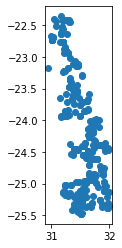

In [188]:
gdf.plot()

In [185]:
gdf['Access'].value_counts(dropna=False).rename_axis('unique_values').reset_index(name='counts')

,unique_values,counts
0,Public,263
1,Private,54
2,Staff,23


In [187]:
gdf['Type'].value_counts(dropna=False).rename_axis('unique_values').reset_index(name='counts')

,unique_values,counts
0,Borehole,118
1,Concession camp,29
2,"Dam, earthen",19
3,Picnic spot,14
4,Bird hide,13
5,Look out point,13
6,Get out point,13
7,Rest camp,12
8,"Dam, concrete",12
9,Ranger camp,11
